In [1]:
from rdkit import Chem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

In [2]:
import time
print(time.asctime())

Wed Feb 18 14:03:52 2026


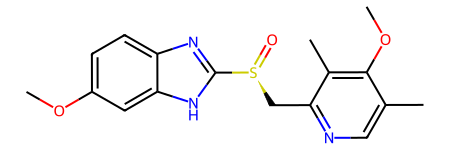

In [3]:
m = Chem.MolFromSmiles('COc1ccc2c(c1)[nH]c(n2)[S@@](=O)Cc1ncc(c(c1C)OC)C')
m

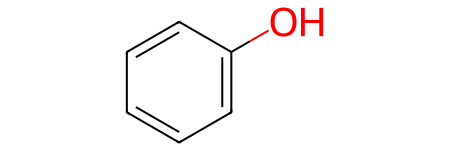

In [4]:
molblock = """phenol
  Mrv1682210081607082D          

  7  7  0  0  0  0            999 V2000
   -0.6473    1.0929    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.3618    0.6804    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.3618   -0.1447    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.6473   -0.5572    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0671   -0.1447    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0671    0.6804    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7816    1.0929    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  2  3  2  0  0  0  0
  3  4  1  0  0  0  0
  4  5  2  0  0  0  0
  5  6  1  0  0  0  0
  1  6  2  0  0  0  0
  6  7  1  0  0  0  0
M  END
"""
m = Chem.MolFromMolBlock(molblock)
m

In [5]:
m.GetNumConformers()

1

In [6]:
m.GetConformer().Is3D()

False

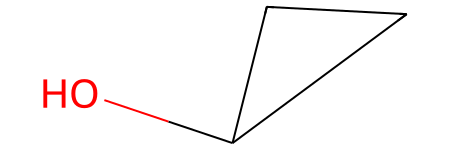

In [7]:
molblock2 ='''cyclopropanol-3D
  Mrv1682210081607153D          

 10 10  0  0  0  0            999 V2000
    0.9159    1.2233    0.2286 C   0  0  1  0  0  0  0  0  0  0  0  0
   -0.0738    1.2748   -0.9428 C   0  0  2  0  0  0  0  0  0  0  0  0
   -0.3167    0.3104    0.2232 C   0  0  2  0  0  0  0  0  0  0  0  0
   -1.3658    0.6623    1.1190 O   0  0  0  0  0  0  0  0  0  0  0  0
    1.8730    0.7413    0.0155 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.8835    2.0739    0.9139 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.2747    0.8266   -1.8737 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.7163    2.1557   -0.9817 H   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1264   -0.7446    0.0137 H   0  0  0  0  0  0  0  0  0  0  0  0
   -1.1210    0.2486    1.9735 H   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  2  3  1  0  0  0  0
  1  3  1  0  0  0  0
  3  4  1  0  0  0  0
  1  5  1  0  0  0  0
  1  6  1  0  0  0  0
  2  7  1  0  0  0  0
  2  8  1  0  0  0  0
  3  9  1  0  0  0  0
  4 10  1  0  0  0  0
M  END
'''
m2 = Chem.MolFromMolBlock(molblock2)
m2

In [8]:
m2.GetConformer().Is3D()

True

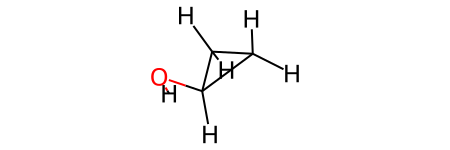

In [9]:
m2_h = Chem.MolFromMolBlock(molblock2,removeHs=False)
m2_h

# Reading PDB data

In [15]:
crn = Chem.MolFromPDBFile('../AI for Drug Discovery/1CRN.pdb')
crn.GetNumAtoms()

327

In [16]:
# get the residue information for each atom:
residues = [atom.GetPDBResidueInfo() for atom in crn.GetAtoms()]
# and now the number and name of each residue
resinf = [(res.GetResidueNumber(),res.GetResidueName()) for res in residues]
# take a look at those:
resinf[:10]

[(1, 'THR'),
 (1, 'THR'),
 (1, 'THR'),
 (1, 'THR'),
 (1, 'THR'),
 (1, 'THR'),
 (1, 'THR'),
 (2, 'THR'),
 (2, 'THR'),
 (2, 'THR')]

In [17]:
# and get the ordered list of actual residues:
residues = sorted(set(resinf))
len(residues)

46

In [18]:
residues[:5]

[(1, 'THR'), (2, 'THR'), (3, 'CYS'), (4, 'CYS'), (5, 'PRO')]

In [19]:
seq = 'TTCCPSIVAR SNFNVCRLPG TPEAICATYT GCIIIPGATC PGDYAN'
m = Chem.MolFromSequence(seq)
m.GetNumAtoms()

327

In [20]:
helm = 'PEPTIDE1{T.T.C.C.P.S.I.V.A.R.S.N.F.N.V.C.R.L.P.G.T.P.E.A.I.C.A.T.Y.T.G.C.I.I.I.P.G.A.T.C.P.G.D.Y.A.N}$$$$'
m = Chem.MolFromHELM(helm)
m.GetNumAtoms()

327

In [21]:
fasta =""">
TTCCPSIVARSNFNVCRLPGTPEAICATYTGCIIIPGATCPGDYAN
"""
m = Chem.MolFromFASTA(fasta)
m.GetNumAtoms()

327